In [40]:
import pandas as pd

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

from sklearn.metrics import classification_report, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, precision_score
from sklearn.ensemble import GradientBoostingClassifier

In [15]:
pd.set_option('display.max_column',None)

In [16]:
df = pd.read_csv(r'C:\Users\mabin\Desktop\DataScienceClassNotes\Career247_Capstone_Project\Fraud_Detection_Project\data\raw\cleaned_data_v5.csv')

In [17]:
df.head()

,transaction_date,payment_method,merchant_category,authentication_method,amount,ip_address_risk_score,device_trust_score,avg_amount_last_24h,device_change_flag,location_change_flag,merchant_historical_fraud_rate,cust_txn_count,cust_fraud_count,cust_fraud_rate,cust_avg_amt,device_count,merchant_fraud_rate,combined_risk,month,day,is_fraud
0,2024-01-01,WALLET,Travel,NONE,556.63,0.041787,0.841375,3294.64,0,0,0.063596,11,0,0.0,9659.361818,11,0.073620,0.029911,1,1,0
1,2024-01-01,CARD,Electronics,OTP,10158.89,0.162148,0.119578,4163.76,1,0,0.057505,11,0,0.0,9659.361818,11,0.099448,0.094997,1,1,0
2,2024-01-10,UPI,Fashion,PIN,15754.57,0.774662,0.718447,5077.26,0,1,0.053729,11,0,0.0,9659.361818,11,0.077844,0.102428,1,10,0
3,2024-01-20,CARD,Utilities,PIN,6095.68,0.259900,0.069586,1187.30,0,0,0.004334,11,0,0.0,9659.361818,11,0.086486,0.032338,1,20,0
4,2024-01-23,CARD,Gaming,OTP,15324.24,0.376711,0.286630,10936.02,0,0,0.131218,11,0,0.0,9659.361818,11,0.096386,0.086691,1,23,0


## Ordinal Encoding

In [18]:
numerical_col = df.select_dtypes(['int','float']).columns.to_list()

if 'is_fraud' in numerical_col:
    numerical_col.remove('is_fraud')
    
categorical_col = df.select_dtypes(['object']).columns.to_list()

if 'transaction_date' in categorical_col:
    categorical_col.remove('transaction_date')

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_col),
        ('cat',OrdinalEncoder(),categorical_col)
    ],
    remainder='passthrough'
)

In [20]:
pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', GradientBoostingClassifier(learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200))
    ])

In [21]:
data = df.copy()

data['transaction_date'] = pd.to_datetime(data['transaction_date'])
    
    
train = data[data['transaction_date'] < '2024-03-01'].copy()
test  = data[data['transaction_date'] >= '2024-03-01'].copy()
    
train = train.drop(columns=['transaction_date'])
test  = test.drop(columns=['transaction_date'])
    
    
X_train = train.drop('is_fraud', axis=1)
y_train = train['is_fraud']

X_test = test.drop('is_fraud', axis=1)
y_test = test['is_fraud']

In [22]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

In [ ]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]


In [ ]:
recall = recall_score(y_test, y_pred)
print("Recall :", recall)


f1 = f1_score(y_test, y_pred)
print("F1-Score", f1)

rou_auc = roc_auc_score(y_test, y_prob)
print("ROU-AUC :", rou_auc)

Recall : 0.7379710144927536
F1-Score 0.4012608353033885
ROU-AUC : 0.8526225567603607


In [26]:
confusion_matrix(y_test,y_pred)

array([[11521,  3347],
       [  452,  1273]])

## One-Hot Encoding

In [33]:
preprocessor_1 = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_col),
        ('cat',OneHotEncoder(drop='first',sparse_output=False),categorical_col)
    ],
    remainder='passthrough'
)

In [34]:
pipeline_1 = Pipeline(steps=[
        ('preprocessor', preprocessor_1),
        ('smote', SMOTE(random_state=42)),
        ('classifier', GradientBoostingClassifier(learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200))
    ])

In [35]:
pipeline_1.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

In [ ]:
y_pred = pipeline_1.predict(X_test)

y_prob = pipeline_1.predict_proba(X_test)[:,1]

In [ ]:
recall = recall_score(y_test, y_pred)
print("Recall :", recall)


f1 = f1_score(y_test, y_pred)
print("F1-Score", f1)

rou_auc = roc_auc_score(y_test, y_prob)
print("ROU-AUC :", rou_auc)

Recall : 0.6701449275362319
F1-Score 0.4061841180604357
ROU-AUC : 0.8496336066564512


In [38]:
confusion_matrix(y_test,y_pred)

array([[12057,  2811],
       [  569,  1156]])

### Comparison of Encoding Techniques

To evaluate the impact of categorical encoding techniques on model performance, both Ordinal Encoding and One-Hot Encoding were applied and compared using Recall, F1-score, ROC-AUC, and the Confusion Matrix.

#### Ordinal Encoding Results

* Recall: 0.738

* F1-score: 0.401

* ROC-AUC: 0.8526

* False Negatives: 452

* False Positives: 3347

The model achieved higher recall with ordinal encoding, meaning it successfully identified a larger proportion of actual positive cases. It also produced a slightly higher ROC-AUC score, indicating strong class separation capability.

#### One-Hot Encoding Results

Recall: 0.670

F1-score: 0.406

ROC-AUC: 0.8496

False Negatives: 569

False Positives: 2811

One-hot encoding slightly improved the F1-score and reduced false positives. However, it resulted in lower recall and a higher number of false negatives compared to ordinal encoding.


* ROC-AUC scores were very similar for both techniques (~0.85), indicating comparable discriminatory power.

* Ordinal encoding achieved higher recall and fewer false negatives.

* One-hot encoding reduced false positives and slightly improved F1-score.

* Since the dataset appears to be imbalanced, recall becomes a critical metric.


#### Final Decision

Considering the higher recall, better ROC-AUC score, and lower number of false negatives, Ordinal Encoding was selected as the final encoding technique.

## Threshold Tuining

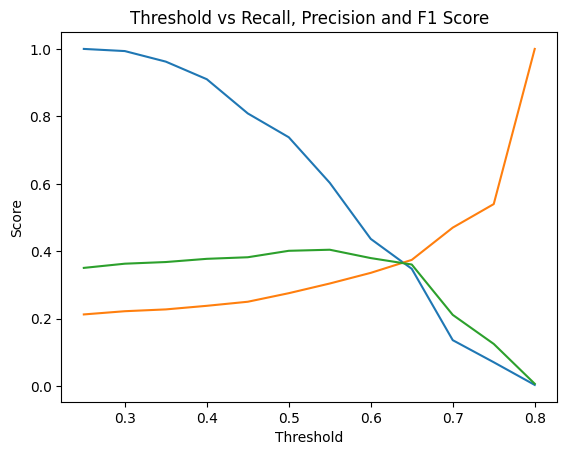

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


y_prob = pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.25, 0.81, 0.05)

recall_list = []
precision_list = []
f1_list = []

for val in thresholds:
    y_pred_custom = (y_prob >= val).astype(int)
    
    recall_list.append(recall_score(y_test, y_pred_custom))
    precision_list.append(precision_score(y_test, y_pred_custom))
    f1_list.append(f1_score(y_test, y_pred_custom))

# Line graph
plt.figure()
plt.plot(thresholds, recall_list)
plt.plot(thresholds, precision_list)
plt.plot(thresholds, f1_list)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Recall, Precision and F1 Score")
plt.show()
    


Based on threshold analysis, 0.5 was selected as it maximized the F1-score while maintaining a reasonable balance between precision and recall.